In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = r"C:\Users\Aaron\OneDrive\Desktop\Capstone\Data\Features"

weather = pd.read_csv(path + "\Weather\Weather_Year_Average_1985_2025.csv")

In [3]:
print(weather.shape)

(41, 4)


In [4]:
weather.head()

,Year,Precipitation,AirTemperature,SunshineDuration
0,1985,80.76,9.31,104.67
1,1986,86.53,8.84,111.62
2,1987,76.00,9.68,102.71
3,1988,86.10,10.05,108.28
4,1989,70.49,10.60,122.36


In [5]:
spring_wheat = pd.read_csv(path + "\CropYield\SpringWheat1985_2025.csv")[['Year','Tonnes']]
winter_wheat = pd.read_csv(path + "\CropYield\WinterWheat1985_2025.csv")[['Year','Tonnes']]
spring_oats = pd.read_csv(path + "\CropYield\SpringOats1985_2025.csv")[['Year','Tonnes']]
winter_oats = pd.read_csv(path + "\CropYield\WinterOats1985_2025.csv")[['Year','Tonnes']]


In [6]:
spring_wheat.head()

,Year,Tonnes
0,1985,5.8
1,1986,5.4
2,1987,6.2
3,1988,7.0
4,1989,6.2


In [7]:
swheat = spring_wheat.rename(columns={'Tonnes': 'SpringWheat'})
wwheat = winter_wheat.rename(columns={'Tonnes': 'WinterWheat'})
soats = spring_oats.rename(columns={'Tonnes': 'SpringOats'})
woats = winter_oats.rename(columns={'Tonnes': 'WinterOats'})

In [8]:
df = weather.merge(swheat, on='Year').merge(wwheat, on='Year').merge(soats, on='Year').merge(woats, on='Year')

In [9]:
print(df.columns.tolist())

['Year', 'Precipitation', 'AirTemperature', 'SunshineDuration', 'SpringWheat', 'WinterWheat', 'SpringOats', 'WinterOats']


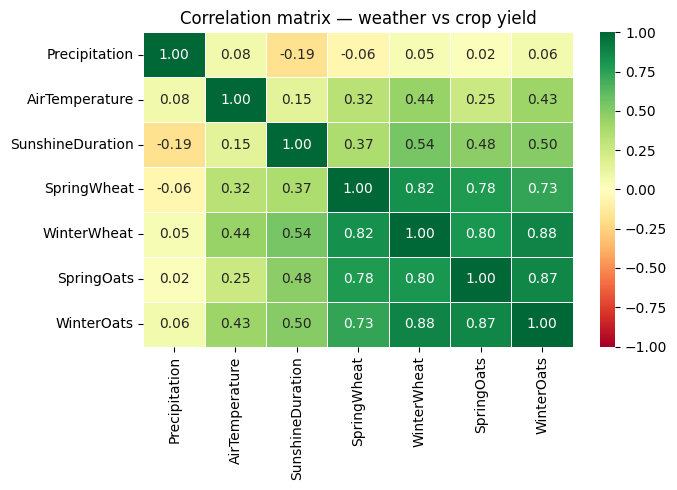

In [10]:
cols = ['Precipitation', 'AirTemperature', 'SunshineDuration', 'SpringWheat', 'WinterWheat', 'SpringOats','WinterOats']
corr = df[cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation matrix — weather vs crop yield')
plt.tight_layout()
plt.show()

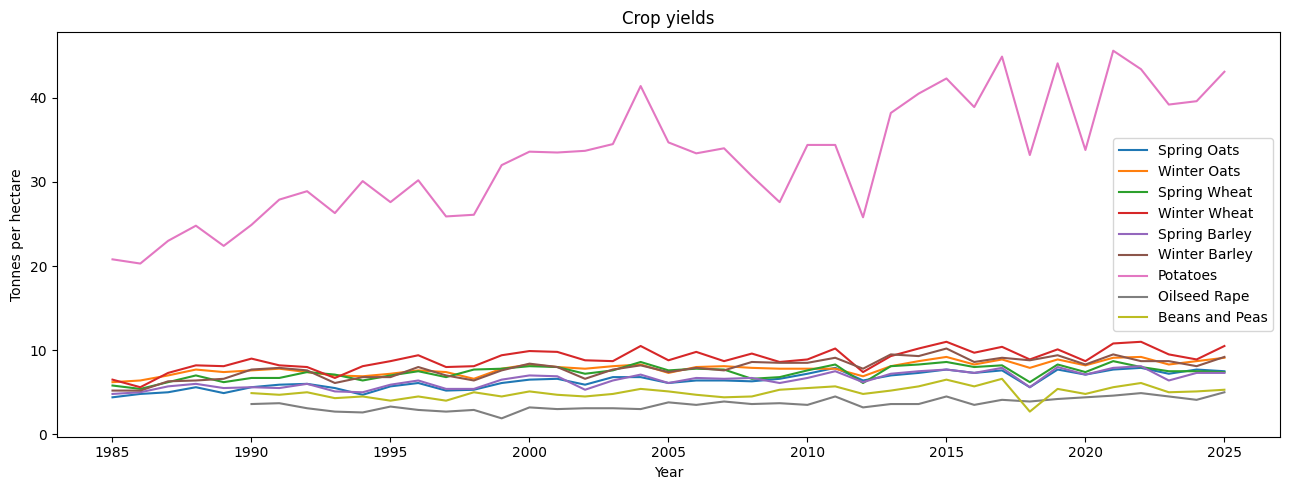

In [11]:
yields  = pd.read_csv(path +  "\CropYield\CombinedYield1985_2025.csv")
df = weather.merge(yields, on='Year')

crop_cols = ['Spring Oats', 'Winter Oats', 'Spring Wheat', 'Winter Wheat','Spring Barley', 'Winter Barley', 'Potatoes', 'Oilseed Rape', 'Beans and Peas']

fig, ax = plt.subplots(figsize=(13, 5))
for crop in crop_cols:
    ax.plot(df['Year'], df[crop], label=crop, linewidth=1.5)
ax.set_title('Crop yields')
ax.set_xlabel('Year')
ax.set_ylabel('Tonnes per hectare')
ax.legend()
plt.tight_layout()
plt.show()

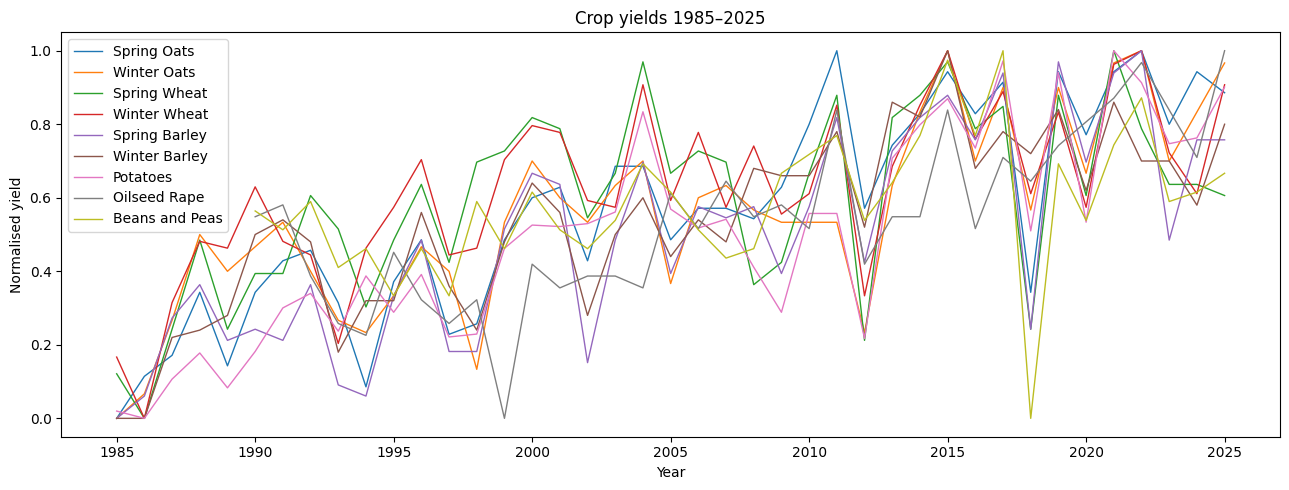

In [12]:
norm = (df[crop_cols] - df[crop_cols].min()) / (df[crop_cols].max() - df[crop_cols].min())
norm['Year'] = df['Year']

fig, ax = plt.subplots(figsize=(13, 5))
for crop in crop_cols:
    ax.plot(norm['Year'], norm[crop], label=crop, linewidth=1)
ax.set_title('Crop yields 1985–2025')
ax.set_xlabel('Year')
ax.set_ylabel('Normalised yield')
ax.legend()
plt.tight_layout()
plt.show()

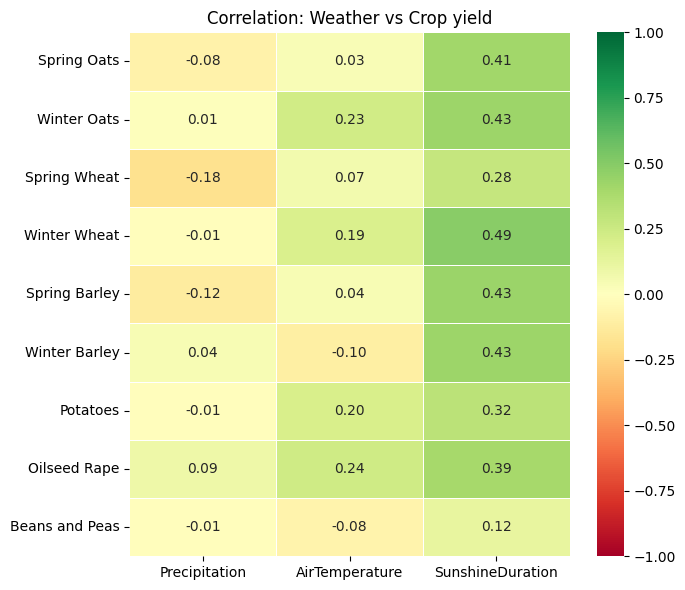

In [13]:
weather_cols = ['Precipitation', 'AirTemperature', 'SunshineDuration']

df_clean = df[weather_cols + crop_cols].dropna()

corr = df_clean.corr().loc[crop_cols, weather_cols]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Correlation: Weather vs Crop yield')
plt.tight_layout()
plt.show()

In [14]:
high_year = yields.loc[yields['Winter Wheat'].idxmax(), 'Year']
low_year  = yields.loc[yields['Winter Wheat'].idxmin(), 'Year']

print(f"High yield year: {int(high_year)} ({yields['Winter Wheat'].max()} t/ha)")
print(f"Low yield year:  {int(low_year)} ({yields['Winter Wheat'].min()} t/ha)")

High yield year: 2015 (11.0 t/ha)
Low yield year:  1986 (5.6 t/ha)


In [19]:
weather_monthly = pd.read_csv(path + '\Weather\Ireland_Weather_1985_2024_Combined.csv')

monthly = weather_monthly[['Year', 'Month', 'Precipitation_National_Avg', 
                            'Temperature_National_Avg', 'Sunshine_National_Avg']].copy()
monthly.columns = ['Year', 'Month', 'Precipitation', 'AirTemperature', 'SunshineDuration']

high_data = monthly[monthly['Year'] == high_year].sort_values('Month')
low_data  = monthly[monthly['Year'] == low_year].sort_values('Month')

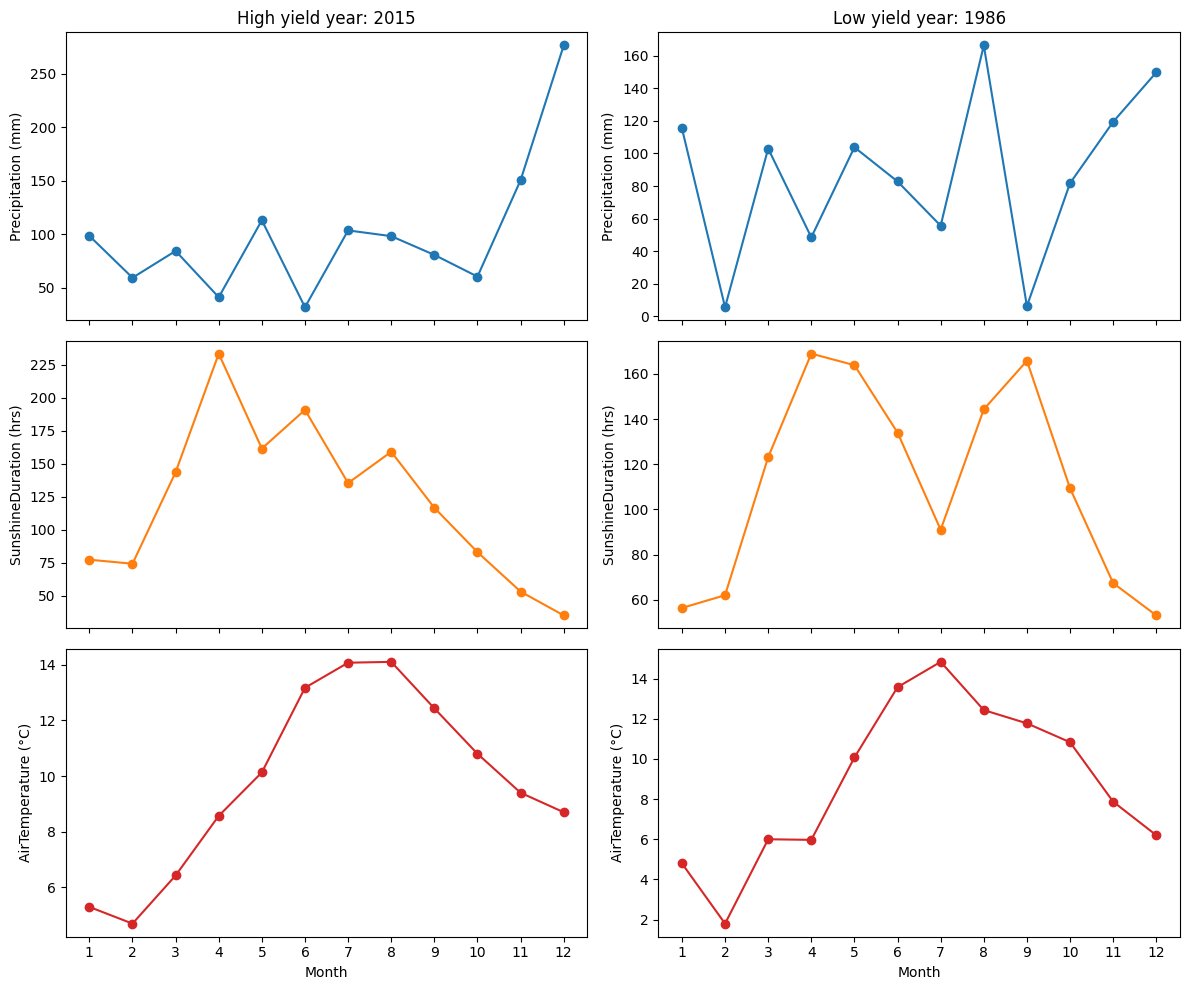

In [21]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

variables = ['Precipitation', 'SunshineDuration', 'AirTemperature']
colors    = ['tab:blue', 'tab:orange', 'tab:red']
units     = ['mm', 'hrs', '°C']

for row, (var, color, unit) in enumerate(zip(variables, colors, units)):
    for col, (data, year, label) in enumerate(zip([high_data, low_data], [high_year, low_year], ['High yield', 'Low yield'])):
        ax = axes[row][col]
        ax.plot(data['Month'], data[var], color=color, marker='o')
        ax.set_xticks(range(1, 13))
        ax.set_ylabel(f'{var} ({unit})')
        if row == 0:
            ax.set_title(f'{label} year: {int(year)}')
        if row == 2:
            ax.set_xlabel('Month')

plt.tight_layout()
plt.show()

In [27]:
sorted_yields = yields[['Year', 'Winter Wheat']].sort_values('Winter Wheat', ascending=False).reset_index(drop=True)

highest_year  = sorted_yields.loc[0, 'Year']
high2_year    = sorted_yields.loc[1, 'Year']
low2_year     = sorted_yields.loc[len(sorted_yields)-2, 'Year']
lowest_year   = sorted_yields.loc[len(sorted_yields)-1, 'Year']

years_to_plot = [highest_year, high2_year, low2_year, lowest_year]
labels        = ['Highest 1st', 'Highest 2nd', 'Lowest 2nd', 'Lowest 1st']

print(sorted_yields.head(2))
print(sorted_yields.tail(2))

   Year  Winter Wheat
0  2022          11.0
1  2015          11.0
    Year  Winter Wheat
39  1985           6.5
40  1986           5.6


In [28]:
data_by_year = {year: monthly[monthly['Year'] == year].sort_values('Month') for year in years_to_plot}

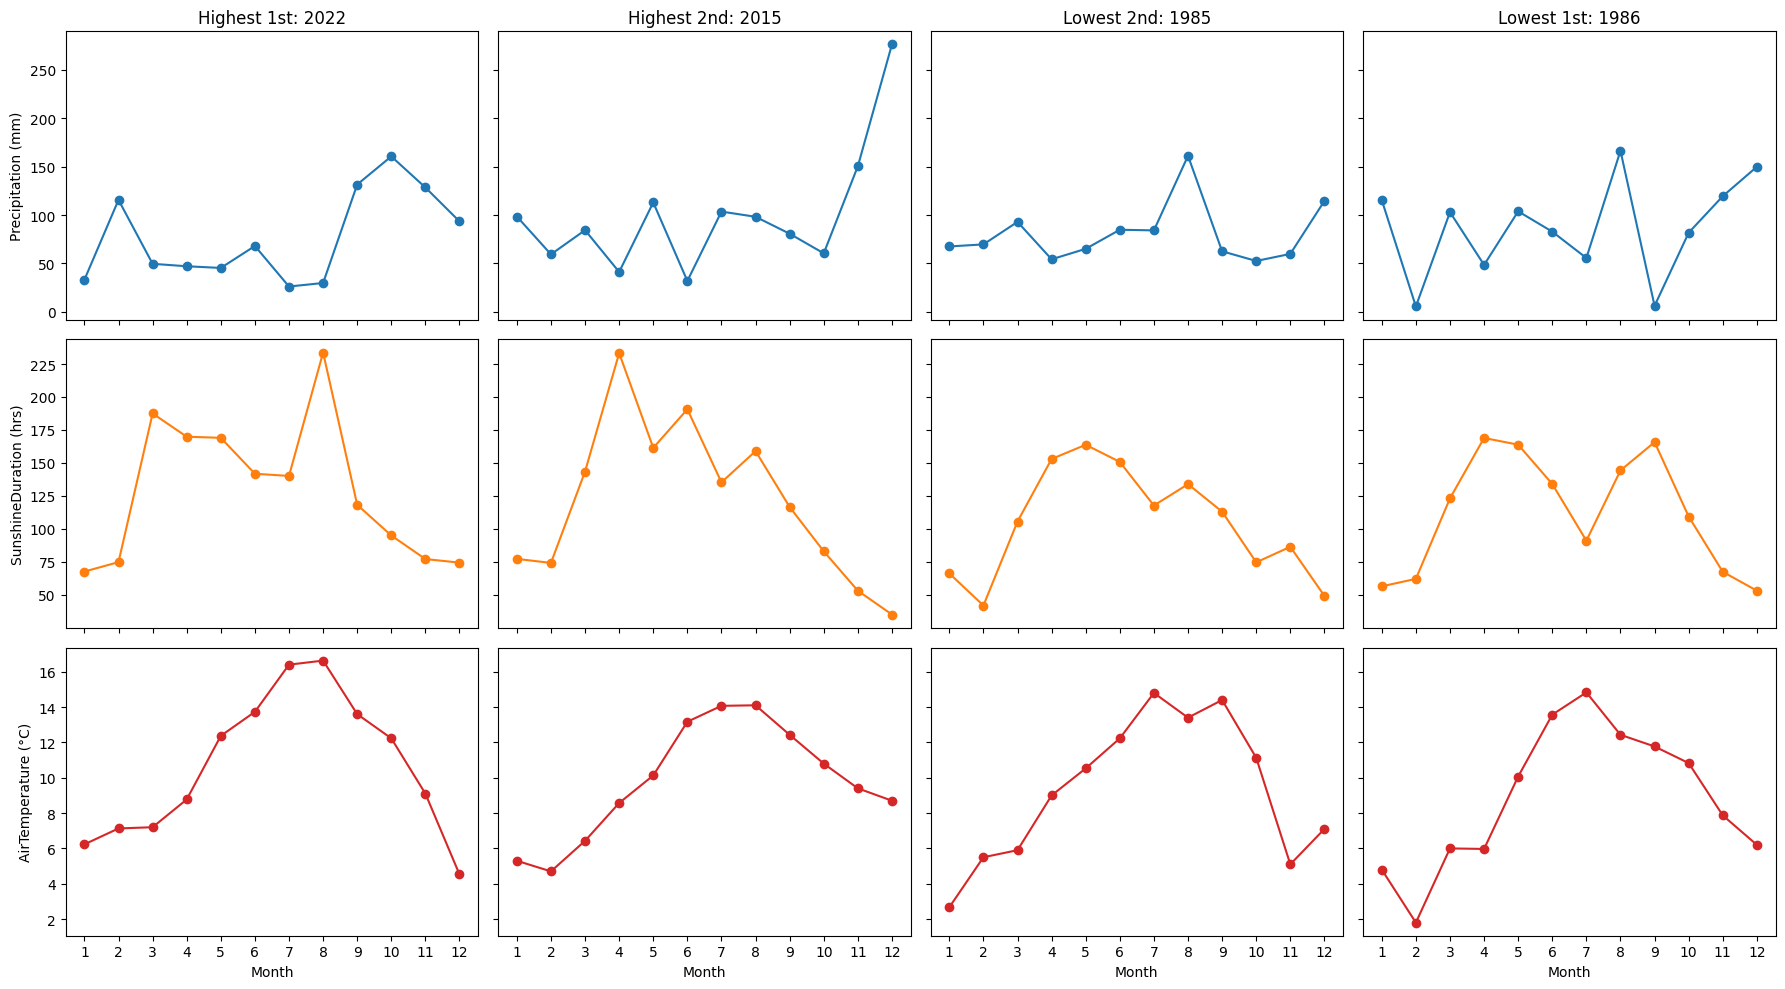

: 

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True, sharey='row')

variables = ['Precipitation', 'SunshineDuration', 'AirTemperature']
colors    = ['tab:blue', 'tab:orange', 'tab:red']
units     = ['mm', 'hrs', '°C']

for row, (var, color, unit) in enumerate(zip(variables, colors, units)):
    for col, (year, label) in enumerate(zip(years_to_plot, labels)):
        ax = axes[row][col]
        data = data_by_year[year]
        ax.plot(data['Month'], data[var], color=color, marker='o')
        ax.set_xticks(range(1, 13))
        if col == 0:
            ax.set_ylabel(f'{var} ({unit})')
        if row == 0:
            ax.set_title(f'{label}: {int(year)}')
        if row == 2:
            ax.set_xlabel('Month')

plt.tight_layout()
plt.show()